# UI-Flow Haptic Pipeline v1

This notebook is the first pipeline step after the behavior atlas. It does **not** call an LLM yet. Instead, it takes a manual `HAPTIC_PLAN`, selects one curated raw-z prototype, decodes one 0.5s VAE chunk, optionally stretches that behavior to a longer duration without repeating full chunks, and inserts it into a 2s silent waveform at the beginning, middle, or end.

In [1]:
# 1. Clone code repo (or force-update to latest)
import os
import subprocess
import sys

REPO_URL = "https://github.com/cindy-77jiayi/thesis_hapticAE.git"
REPO_DIR = "/content/thesis_hapticAE"
BRANCH = 'altas'
FORCE_CLEAN_CLONE = False

if FORCE_CLEAN_CLONE and os.path.exists(REPO_DIR):
    subprocess.run(["rm", "-rf", REPO_DIR], check=True)

if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    clone_cmd = ["git", "clone", REPO_URL, REPO_DIR]
    if BRANCH:
        clone_cmd = ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_DIR]
    subprocess.run(clone_cmd, check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "--all"], check=False)
    if BRANCH:
        subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=False)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"Repo ready at: {REPO_DIR}")

Repo ready at: /content/thesis_hapticAE


In [24]:
# -----------------------------
# Editable notebook parameters
# -----------------------------
from pathlib import Path

CONFIG_PATH = "configs/vae_balanced_8d_0p5s.yaml"
CHECKPOINT_PATH_OVERRIDE = "/content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/best_model.pt"
REPO_URL = "https://github.com/cindy-77jiayi/thesis_hapticAE.git"
REPO_BRANCH = "altas"
REPO_DIR = Path("/content/thesis")

DRIVE_ROOT = Path("/content/drive/MyDrive/thesis_outputs")
OUTPUTS_ROOT = DRIVE_ROOT / "outputs"
ATLAS_DIR = DRIVE_ROOT / "behavior_atlas_8class"
CURATED_JSON_PATH = ATLAS_DIR / "curated_behavior_prototypes.json"
ATLAS_JSON_PATH = ATLAS_DIR / "behavior_atlas.json"
PIPELINE_OUTPUT_DIR = DRIVE_ROOT / "ui_flow_haptic_v1"

# v1 supports exactly one behavior per run.
# placement: "beginning", "middle", or "end"
# duration_s: 0.5, 1.0, or 2.0 are the main intended values.
# duration_mode: "hold_stretch" keeps each sample value for longer, preserving amplitude height.
HAPTIC_PLAN = {
    "interaction_type": "slider_drag",
    "behavior": {
        "class": "long_rising",
        "strength": 0.7,
        "placement": "beginning",
        "duration_s": 1.5,
        "duration_mode": "hold_stretch",
        "prototype_policy": "curated_first",
        "prototype_index": 0,
    },
}

GENERATED_BASENAME = "generated_haptic"
FINAL_DURATION_S = 2.0
FADE_MS = 10.0

## Future LLM Contract

Later, a multimodal LLM should read `before`, `during`, and `after` UI screenshots and output the same plan shape used above. It should choose exactly one behavior class for v1.

Allowed classes:
- `quiet_or_subtle`
- `single_short_pulse`
- `double_short_pulse`
- `multi_short_pulse`
- `long_sustained`
- `long_rising`
- `long_falling`
- `long_modulated_or_pulsed`

Allowed placements:
- `beginning`
- `middle`
- `end`

Duration fields:
- `duration_s`: target duration of the decoded behavior within the 2s output. Use `0.5`, `1.0`, or `2.0` first.
- `duration_mode`: use `hold_stretch` to keep sample heights and make the behavior last longer without repeating chunks. `linear_stretch` is available for smoother interpolation.

For now, edit `HAPTIC_PLAN` manually and run the notebook top to bottom.

In [25]:
# -----------------------------
# Setup, Drive mount, imports
# -----------------------------
import json
import os
import subprocess
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Audio, display
from scipy.io.wavfile import write as wav_write

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Google Drive mount skipped or unavailable: {exc}")

def resolve_project_root() -> Path:
    current = Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists():
            return candidate

    if not (REPO_DIR / ".git").exists():
        print(f"Repository not found at {REPO_DIR}; cloning {REPO_BRANCH}...")
        subprocess.run([
            "git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)
        ], check=True)
    else:
        print(f"Repository found at {REPO_DIR}; updating {REPO_BRANCH}...")
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", REPO_BRANCH], check=False)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], check=False)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_BRANCH], check=False)

    if not (REPO_DIR / "src").exists():
        raise FileNotFoundError(f"Could not find src/ in current directory or cloned repo: {REPO_DIR}")
    return REPO_DIR


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loaders import build_model, load_checkpoint
from src.utils.config import load_config

PIPELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Pipeline output dir: {PIPELINE_OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/thesis_hapticAE
Pipeline output dir: /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1


In [26]:
# -----------------------------
# File resolution and atlas helpers
# -----------------------------
def resolve_checkpoint(outputs_root: Path, override: str | None = None) -> Path:
    if override:
        path = Path(override)
        if not path.exists():
            raise FileNotFoundError(f"CHECKPOINT_PATH_OVERRIDE does not exist: {path}")
        print(f"Using override checkpoint: {path}")
        return path

    if not outputs_root.exists():
        raise FileNotFoundError(f"OUTPUTS_ROOT does not exist: {outputs_root}")

    candidates = []
    for name in ("best_model.pt", "last_checkpoint.pt"):
        candidates.extend(outputs_root.rglob(name))
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No best_model.pt or last_checkpoint.pt found under: {outputs_root}")

    print("Checkpoint candidates, newest first:")
    for idx, path in enumerate(candidates[:10]):
        print(f"  [{idx}] {path}")
    print(f"Selected checkpoint: {candidates[0]}")
    return candidates[0]


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_prototype_source(curated_path: Path, atlas_path: Path) -> tuple[dict | None, dict | None]:
    curated = load_json(curated_path) if curated_path.exists() else None
    atlas = load_json(atlas_path) if atlas_path.exists() else None
    if curated is None and atlas is None:
        raise FileNotFoundError(
            f"Missing both curated prototype file and atlas file:\n  {curated_path}\n  {atlas_path}"
        )
    if curated is not None:
        print(f"Loaded curated prototypes: {curated_path}")
    else:
        print(f"Curated prototypes not found, using atlas only: {atlas_path}")
    if atlas is not None:
        print(f"Loaded atlas: {atlas_path}")
    return curated, atlas


def prototype_from_class(
    behavior_class: str,
    curated: dict | None,
    atlas: dict | None,
    prototype_index: int = 0,
) -> dict | None:
    if curated is not None:
        class_entry = curated.get("classes", {}).get(behavior_class, {})
        approved = class_entry.get("approved_prototypes", []) or []
        if approved:
            idx = min(max(int(prototype_index), 0), len(approved) - 1)
            proto = dict(approved[idx])
            proto["selection_source"] = "curated.approved_prototypes"
            proto["selection_index"] = idx
            return proto
        fallback = class_entry.get("fallback_prototype")
        if fallback:
            proto = dict(fallback)
            proto["selection_source"] = "curated.fallback_prototype"
            proto["selection_index"] = 0
            return proto

    if atlas is not None:
        prototypes = atlas.get("classes", {}).get(behavior_class, {}).get("prototype_z", []) or []
        if prototypes:
            idx = min(max(int(prototype_index), 0), len(prototypes) - 1)
            proto = dict(prototypes[idx])
            proto["selection_source"] = "atlas.prototype_z"
            proto["selection_index"] = idx
            return proto

    return None


def validate_plan(plan: dict) -> dict:
    behavior = dict(plan.get("behavior", {}))
    if "class" not in behavior:
        raise ValueError("HAPTIC_PLAN['behavior']['class'] is required")
    behavior["strength"] = float(np.clip(float(behavior.get("strength", 0.7)), 0.0, 1.0))
    behavior["placement"] = str(behavior.get("placement", "middle"))
    if behavior["placement"] not in {"beginning", "middle", "end"}:
        raise ValueError("placement must be one of: beginning, middle, end")
    behavior["duration_s"] = float(behavior.get("duration_s", 0.5))
    if behavior["duration_s"] <= 0:
        raise ValueError("duration_s must be positive")
    if behavior["duration_s"] > FINAL_DURATION_S:
        raise ValueError(f"duration_s must be <= FINAL_DURATION_S ({FINAL_DURATION_S})")
    behavior["duration_mode"] = str(behavior.get("duration_mode", "hold_stretch"))
    if behavior["duration_mode"] not in {"none", "hold_stretch", "linear_stretch"}:
        raise ValueError("duration_mode must be one of: none, hold_stretch, linear_stretch")
    behavior["prototype_index"] = int(behavior.get("prototype_index", 0))
    return behavior

In [27]:
# -----------------------------
# Load VAE, checkpoint, and atlas files
# -----------------------------
config = load_config(str(PROJECT_ROOT / CONFIG_PATH))
sr = int(config["data"]["sr"])
chunk_len = int(config["data"]["T"])
latent_dim = int(config["model"]["latent_dim"])
final_len = int(round(FINAL_DURATION_S * sr))
clip_range = config.get("loss", {}).get("clamp_range", None)
data_clip_range = config.get("data", {}).get("clip_range", None)
if clip_range is None and data_clip_range is not None:
    clip_abs = max(abs(float(data_clip_range[0])), abs(float(data_clip_range[1])))
else:
    clip_abs = float(clip_range or 5.0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = resolve_checkpoint(OUTPUTS_ROOT, CHECKPOINT_PATH_OVERRIDE)
curated_data, atlas_data = load_prototype_source(CURATED_JSON_PATH, ATLAS_JSON_PATH)

model = build_model(config, device)
load_checkpoint(model, str(checkpoint_path), device)
model.eval()

print(f"Device: {device}")
print(f"sr={sr}, chunk_len={chunk_len}, final_len={final_len}, latent_dim={latent_dim}")
print(f"clip_abs={clip_abs}")

Using override checkpoint: /content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/best_model.pt
Loaded curated prototypes: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/curated_behavior_prototypes.json
Loaded atlas: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/behavior_atlas.json
Device: cuda
sr=8000, chunk_len=4000, final_len=16000, latent_dim=12
clip_abs=3.0


In [28]:
# -----------------------------
# Decode one behavior and insert it into 2s silence
# -----------------------------
def decode_z(z_values: list[float] | np.ndarray) -> np.ndarray:
    z = np.asarray(z_values, dtype=np.float32).reshape(1, -1)
    if z.shape[1] != latent_dim:
        raise ValueError(f"Expected latent_dim={latent_dim}, got z shape {z.shape}")
    z_t = torch.from_numpy(z).to(device)
    with torch.no_grad():
        decoded = model.decode(z_t, target_len=chunk_len)
    return decoded[0, 0].detach().cpu().numpy().astype(np.float32)


def fade_edges(x: np.ndarray, sr: int, fade_ms: float) -> np.ndarray:
    y = np.asarray(x, dtype=np.float32).copy()
    fade_n = int(round(sr * fade_ms / 1000.0))
    fade_n = max(0, min(fade_n, len(y) // 2))
    if fade_n > 1:
        ramp = np.linspace(0.0, 1.0, fade_n, dtype=np.float32)
        y[:fade_n] *= ramp
        y[-fade_n:] *= ramp[::-1]
    return y


def stretch_waveform(x: np.ndarray, target_len: int, mode: str = "hold_stretch") -> np.ndarray:
    """Stretch one decoded 0.5s behavior without repeating full chunks.

    hold_stretch duplicates sample values so amplitudes keep the same height
    for more frames. linear_stretch interpolates for a smoother version.
    """
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    target_len = int(target_len)
    if target_len <= 0:
        raise ValueError("target_len must be positive")
    if mode == "none" or target_len == len(x):
        return x.copy()
    if mode == "hold_stretch":
        source_idx = np.floor(np.arange(target_len) * len(x) / target_len).astype(np.int64)
        source_idx = np.clip(source_idx, 0, len(x) - 1)
        return x[source_idx].astype(np.float32)
    if mode == "linear_stretch":
        old_pos = np.linspace(0.0, 1.0, len(x), dtype=np.float32)
        new_pos = np.linspace(0.0, 1.0, target_len, dtype=np.float32)
        return np.interp(new_pos, old_pos, x).astype(np.float32)
    raise ValueError(f"Unsupported duration_mode: {mode}")


def placement_start_index(placement: str, final_len: int, chunk_len: int) -> int:
    if placement == "beginning":
        return 0
    if placement == "middle":
        return (final_len - chunk_len) // 2
    if placement == "end":
        return final_len - chunk_len
    raise ValueError(f"Unsupported placement: {placement}")


behavior = validate_plan(HAPTIC_PLAN)
behavior_class = behavior["class"]
strength = behavior["strength"]
placement = behavior["placement"]
duration_s = behavior["duration_s"]
duration_mode = behavior["duration_mode"]
prototype_index = behavior["prototype_index"]

selected_proto = prototype_from_class(
    behavior_class,
    curated=curated_data,
    atlas=atlas_data,
    prototype_index=prototype_index,
)

target_chunk_len = int(round(duration_s * sr))
target_chunk_len = min(max(target_chunk_len, 1), final_len)
final_wave = np.zeros(final_len, dtype=np.float32)

if selected_proto is None:
    raw_decoded_chunk = np.zeros(chunk_len, dtype=np.float32)
    decoded_chunk = stretch_waveform(raw_decoded_chunk, target_chunk_len, mode=duration_mode)
    selection_summary = {
        "behavior_class": behavior_class,
        "selection_source": "none_silence",
        "sample_index": None,
        "file_path": None,
        "gain": 0.0,
    }
else:
    raw_decoded_chunk = decode_z(selected_proto["z"])
    gain = 0.5 + 0.8 * strength
    raw_decoded_chunk = raw_decoded_chunk * gain
    decoded_chunk = stretch_waveform(raw_decoded_chunk, target_chunk_len, mode=duration_mode)
    decoded_chunk = fade_edges(decoded_chunk, sr=sr, fade_ms=FADE_MS)
    decoded_chunk = np.clip(decoded_chunk, -clip_abs, clip_abs).astype(np.float32)
    selection_summary = {
        "behavior_class": behavior_class,
        "selection_source": selected_proto.get("selection_source"),
        "selection_index": selected_proto.get("selection_index"),
        "sample_index": selected_proto.get("sample_index"),
        "file_path": selected_proto.get("file_path"),
        "atlas_class": selected_proto.get("atlas_class"),
        "curated_class": selected_proto.get("curated_class"),
        "gain": gain,
    }

actual_chunk_len = len(decoded_chunk)
start_idx = placement_start_index(placement, final_len=final_len, chunk_len=actual_chunk_len)
end_idx = start_idx + actual_chunk_len
final_wave[start_idx:end_idx] = decoded_chunk
final_wave = np.clip(final_wave, -clip_abs, clip_abs).astype(np.float32)
selection_summary.update({
    "duration_s": duration_s,
    "duration_mode": duration_mode,
    "original_chunk_len": int(chunk_len),
    "target_chunk_len": int(target_chunk_len),
    "actual_chunk_len": int(actual_chunk_len),
})

print("Selected behavior:")
print(json.dumps({"plan": HAPTIC_PLAN, "selection": selection_summary}, indent=2))
print(f"placement={placement}, start_idx={start_idx}, end_idx={end_idx}")
print(f"duration_s={duration_s}, duration_mode={duration_mode}, actual_chunk_len={actual_chunk_len}")
print(f"chunk max={np.max(np.abs(decoded_chunk)):.4f}, final max={np.max(np.abs(final_wave)):.4f}")

Selected behavior:
{
  "plan": {
    "interaction_type": "slider_drag",
    "behavior": {
      "class": "long_rising",
      "strength": 0.7,
      "placement": "beginning",
      "duration_s": 1.5,
      "duration_mode": "hold_stretch",
      "prototype_policy": "curated_first",
      "prototype_index": 0
    }
  },
  "selection": {
    "behavior_class": "long_rising",
    "selection_source": "curated.approved_prototypes",
    "selection_index": 0,
    "sample_index": 43,
    "file_path": "/content/hapticgen-dataset/uservoted/pulling_your_luggage_in_excitement_as_your_are_goi_QDHS25_modelB_2.wav",
    "atlas_class": "long_rising",
    "curated_class": "long_rising",
    "gain": 1.06,
    "duration_s": 1.5,
    "duration_mode": "hold_stretch",
    "original_chunk_len": 4000,
    "target_chunk_len": 12000,
    "actual_chunk_len": 12000
  }
}
placement=beginning, start_idx=0, end_idx=12000
duration_s=1.5, duration_mode=hold_stretch, actual_chunk_len=12000
chunk max=0.8711, final max=0.8

In [29]:
# -----------------------------
# Save generated files
# -----------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = PIPELINE_OUTPUT_DIR / f"{GENERATED_BASENAME}_{behavior_class}_{placement}_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)

npy_path = run_dir / f"{GENERATED_BASENAME}.npy"
wav_path = run_dir / f"{GENERATED_BASENAME}.wav"
plan_path = run_dir / "haptic_plan.json"
preview_path = run_dir / "waveform_preview.png"

np.save(npy_path, final_wave)
wav_write(wav_path, sr, final_wave.astype(np.float32))

saved_plan = {
    "haptic_plan": HAPTIC_PLAN,
    "selection": selection_summary,
    "sr": sr,
    "final_duration_s": FINAL_DURATION_S,
    "final_len": final_len,
    "original_chunk_len": chunk_len,
    "target_chunk_len": target_chunk_len,
    "actual_chunk_len": actual_chunk_len,
    "duration_s": duration_s,
    "duration_mode": duration_mode,
    "placement": placement,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "checkpoint_path": str(checkpoint_path),
    "curated_json_path": str(CURATED_JSON_PATH),
    "atlas_json_path": str(ATLAS_JSON_PATH),
}
with open(plan_path, "w", encoding="utf-8") as f:
    json.dump(saved_plan, f, indent=2)

print(f"Saved output directory: {run_dir}")
print(f"WAV:  {wav_path}")
print(f"NPY:  {npy_path}")
print(f"PLAN: {plan_path}")

Saved output directory: /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1/generated_haptic_long_rising_beginning_20260422_080502
WAV:  /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1/generated_haptic_long_rising_beginning_20260422_080502/generated_haptic.wav
NPY:  /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1/generated_haptic_long_rising_beginning_20260422_080502/generated_haptic.npy
PLAN: /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1/generated_haptic_long_rising_beginning_20260422_080502/haptic_plan.json


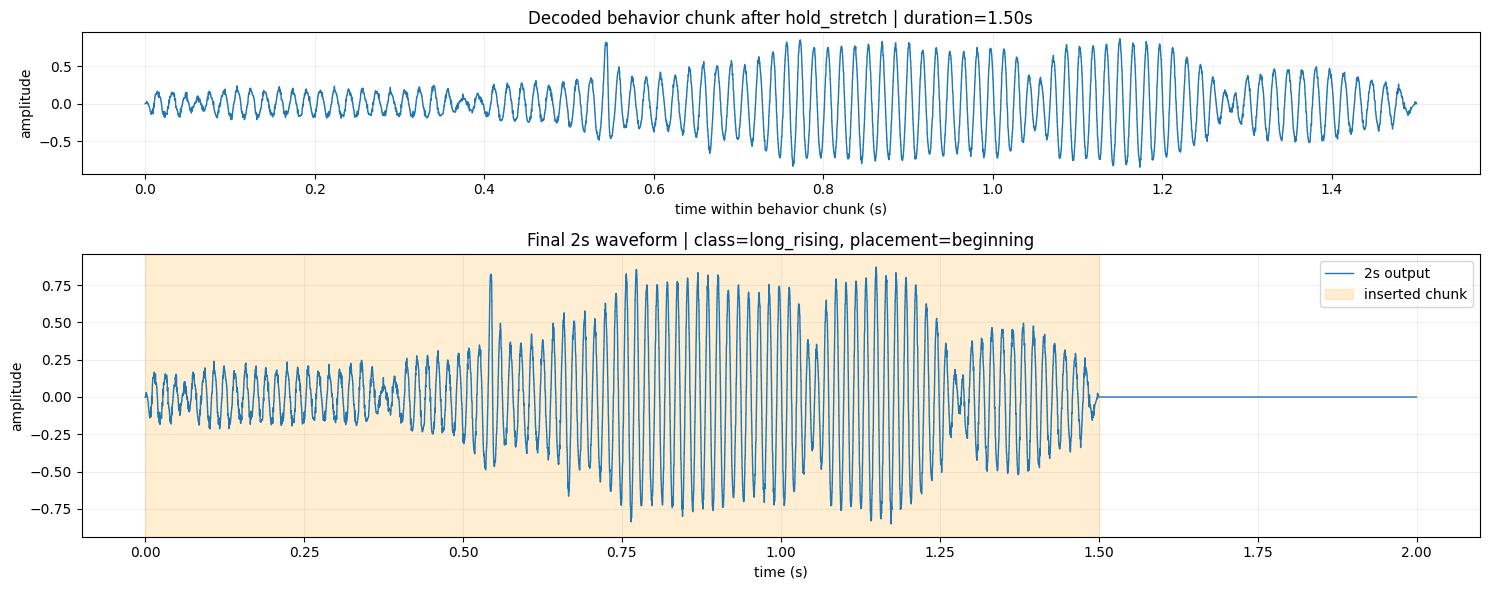

Saved preview: /content/drive/MyDrive/thesis_outputs/ui_flow_haptic_v1/generated_haptic_long_rising_beginning_20260422_080502/waveform_preview.png


In [30]:
# -----------------------------
# Plot and playback
# -----------------------------
time_final = np.arange(final_len) / sr
time_chunk = np.arange(actual_chunk_len) / sr

fig, axes = plt.subplots(2, 1, figsize=(15, 6), gridspec_kw={"height_ratios": [1, 2]})
axes[0].plot(time_chunk, decoded_chunk, linewidth=1.0)
axes[0].set_title(f"Decoded behavior chunk after {duration_mode} | duration={actual_chunk_len / sr:.2f}s")
axes[0].set_xlabel("time within behavior chunk (s)")
axes[0].set_ylabel("amplitude")
axes[0].grid(alpha=0.2)

axes[1].plot(time_final, final_wave, linewidth=1.0, label="2s output")
axes[1].axvspan(start_idx / sr, end_idx / sr, color="orange", alpha=0.18, label="inserted chunk")
axes[1].set_title(f"Final 2s waveform | class={behavior_class}, placement={placement}")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("amplitude")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(preview_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved preview: {preview_path}")
display(Audio(final_wave, rate=sr))

In [31]:
# -----------------------------
# Smoke assertions for v1 behavior
# -----------------------------
expected_starts = {
    "beginning": 0,
    "middle": (final_len - actual_chunk_len) // 2,
    "end": final_len - actual_chunk_len,
}
assert len(final_wave) == 16000, f"Expected 16000 samples for 2s at 8kHz, got {len(final_wave)}"
assert chunk_len == 4000, f"Expected original 4000-sample VAE chunk, got {chunk_len}"
assert 1 <= actual_chunk_len <= final_len, (actual_chunk_len, final_len)
assert start_idx == expected_starts[placement], (placement, start_idx, expected_starts[placement])

outside = final_wave.copy()
outside[start_idx:end_idx] = 0.0
assert np.max(np.abs(outside)) < 1e-7, "Samples outside the inserted 0.5s region should remain silent"

print("Smoke checks passed.")
print(f"actual chunk length: {actual_chunk_len} samples ({actual_chunk_len / sr:.2f}s)")
print(f"beginning start index for this duration: {expected_starts['beginning']}")
print(f"middle start index for this duration:    {expected_starts['middle']}")
print(f"end start index for this duration:       {expected_starts['end']}")

Smoke checks passed.
actual chunk length: 12000 samples (1.50s)
beginning start index for this duration: 0
middle start index for this duration:    2000
end start index for this duration:       4000
